In [232]:
from stuff import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [233]:
np.random.seed(117117)

In [234]:
orig_df = pd.read_csv("data.csv")

In [235]:
orig_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [236]:
df = orig_df.copy()

### Добавим невероятно информативный признак...

In [237]:
df["deck"] = orig_df["Cabin"].map(lambda x: x[0], na_action='ignore')

In [238]:
df.drop(["PassengerId", "Cabin", "Name"], axis=1, inplace=True)
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,deck
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F
...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,A
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,G
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,G
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,E


In [239]:
binary = ["CryoSleep", "VIP", "Transported"]
categorical = ["HomePlanet", "Destination", "deck"]
numerical = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Age"]

### Для простоты выкинем все невалидные значения:

In [240]:
print(df.shape)
df = df.dropna()
print(df.shape)

(8693, 12)
(6764, 12)


In [241]:
df.isna().sum().sum()

np.int64(0)

### Посмотрим на самое интересное - деньги.
### Рассмотрим траты на Spa в зависимости от планеты назначения.

### Можно отметить, что большая часть людей тратит очень мало
### Но есть относительно небольшое количество людей которые спускают всё что есть на Spa.
### Гистограммы построенны в логарифмической шкале, но, даже так, ясно, что нет никакой надежды на то, что распределение является нормальным

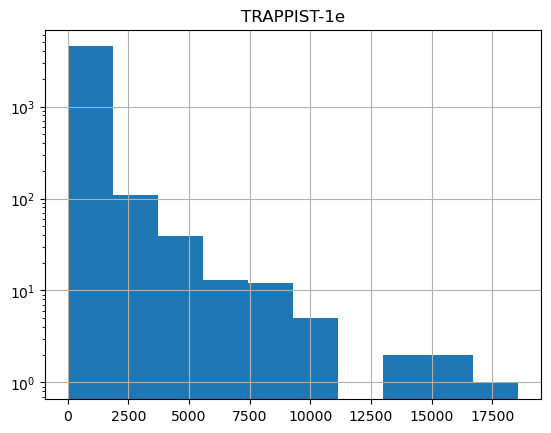

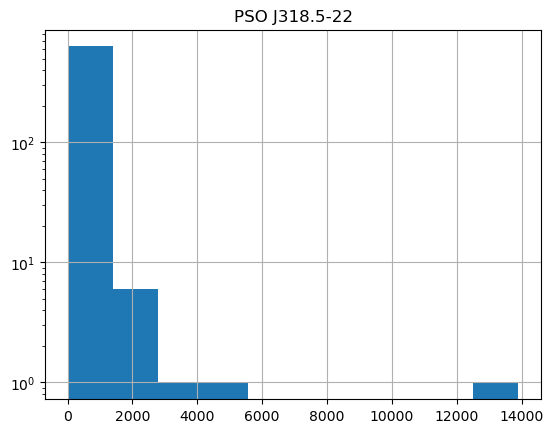

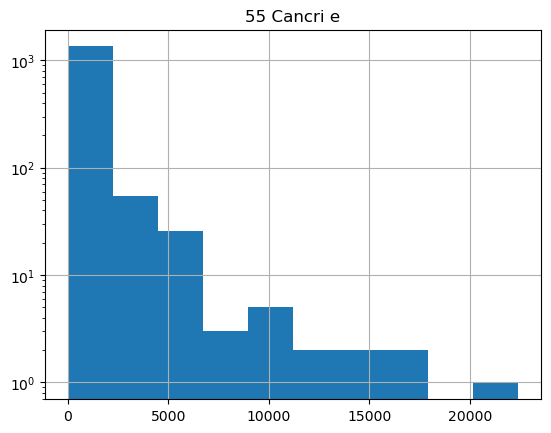

In [242]:
for pl in df["Destination"].unique():
    df[df["Destination"]==pl].hist(column="Spa", log=True)
    plt.title(pl)
    plt.show()


### Теперь посмотрим на распределение возраста в зависимости от deck
### В данной ситуации уже больше оснований полагать что распределение является нормальным, хотя есть заметный скос вправо.

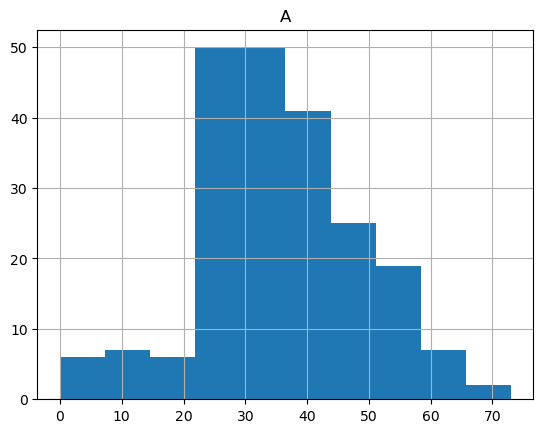

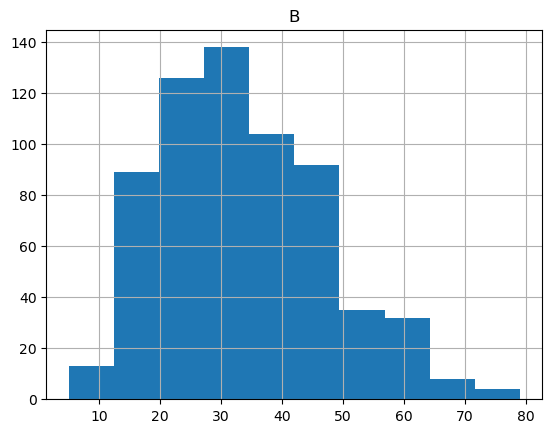

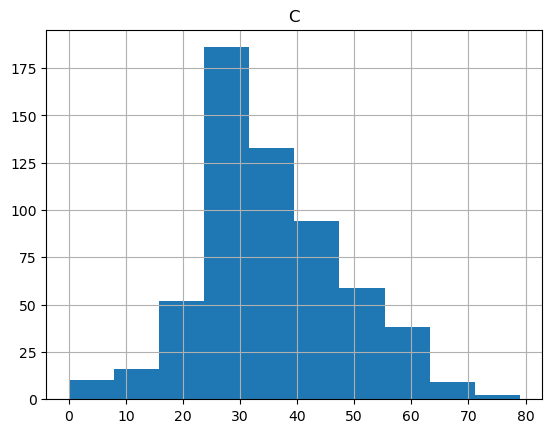

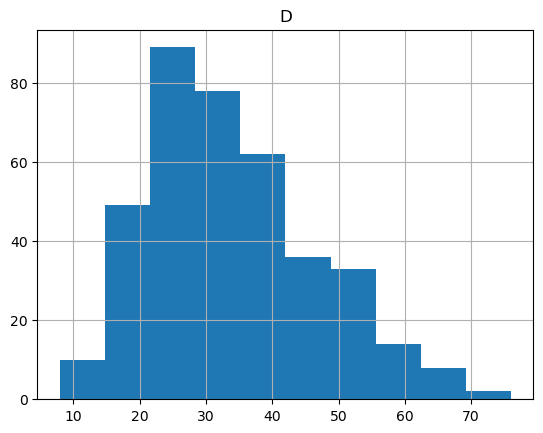

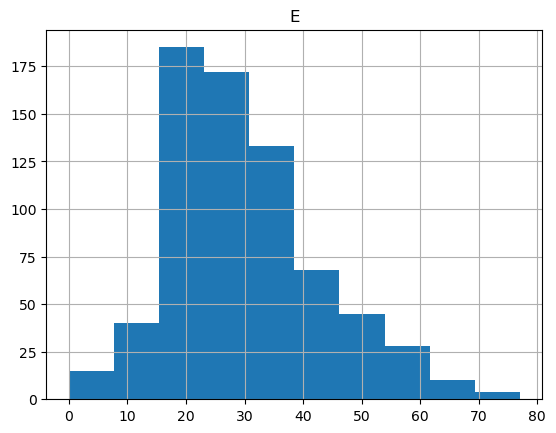

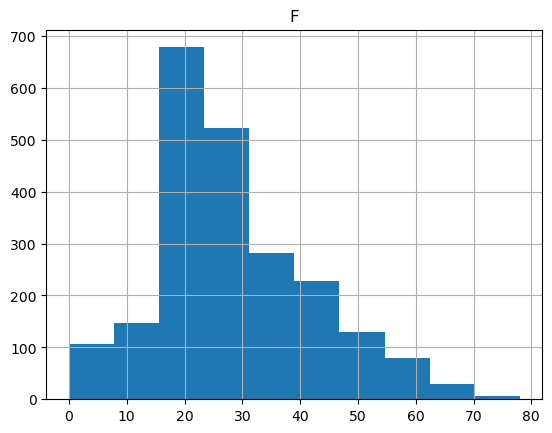

In [243]:
for l in "ABCDEF":
    df[df["deck"]==l].hist(column="Age")
    plt.title(l)
    plt.plot()

### При некоторых предположениях для проверки гипотезы о равенстве распределений можно использовать anova

In [244]:
std = 3.14
anova_p, var_est, n, k = anova([
    np.random.normal(10, std, 1000),
    np.random.normal(10.01, std, 1000),
    np.random.normal(9.99, std, 1000),
    np.random.normal(9.95, std, 1000)
])
print(f"pval = {anova_p:.4f}")

pval = 0.8484


In [245]:
std = 3.14
anova_p, var_est, n, k = anova([
    np.random.normal(10, std, 1000),
    np.random.normal(10.1, std, 1000),
    np.random.normal(9.5, std, 1000),
    np.random.normal(9.8, std, 1000)
])
print(f"pval = {anova_p:.4f}")

pval = 0.0050


### Забудем про шапиро и сделаем вид, что распределение действительно нормальное

In [246]:
groups = [ df[df["deck"]==d]["Age"] for d in "ABCDEF"]
data = groups[1]
stat, pvalue = stats.shapiro(data)
print(f"Shapiro-Wilk: statistic={stat:.4f}, p-value={pvalue:.4f}")


Shapiro-Wilk: statistic=0.9776, p-value=0.0000


### anova требует равенства дисперсий.
### в этом плане все хорошо

In [247]:
df[df["deck"].isin(list("ABCDEF"))].groupby("deck")["Age"].std()

deck
A    13.163758
B    13.347771
C    12.833739
D    12.665104
E    12.824299
F    13.632416
Name: Age, dtype: float64

In [248]:
groups = [ df[df["deck"]==d]["Age"] for d in "ABCDEF"]
stat,pval = stats.levene(*groups)
print(f"stat = {stat}\npval = {pval}")

stat = 0.7129427510577947
pval = 0.6136510300109776


### Есть основания полгагать, что Age и deck связаны

In [249]:
df.groupby("deck")["Age"].mean()

deck
A    35.798122
B    33.647426
C    35.298831
D    33.944882
E    30.175714
F    28.370471
G    23.929668
T    37.666667
Name: Age, dtype: float64

### Ожидаемо, при любом разумном уровне значимости гипотеза о равенстве средних отвергается

In [250]:
groups = [ df[df["deck"]==d]["Age"] for d in "ABCDEF"]
pval, var_estimator, n, k = anova(groups)
print(f"pval = {pval} \nvar_est = {var_estimator}")

pval = 0.0 
var_est = 176.3771813885586


### Теперь посмотрим на попарные различия

### Между какими-то палубами действительно есть статистически значимое различие (при разумных уровнях значимости типа 0.05), а между какими-то нет.

In [264]:
groups = [ df[df["deck"]==d]["Age"] for d in "ABCDEF"]
cnt_comparisons = len(groups) * (len(groups) - 1) / 2 

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        print(f"for groups {"ABCDEF"[i]} and {"ABCDEF"[j]}")
        pval, (l, r) = ttest(groups[i], groups[j], var_estimator, n, k)
        # bonferroni
        corr_pval = min(cnt_comparisons * pval, 1)
        print(f"corrected pval = {corr_pval:.4f}")
        print(f"0.95% conf int for diff in means:\n({l:.4f}, {r:.4f})")
        print()


for groups A and B
corrected pval = 0.6098
0.95% conf int for diff in means:
(0.0915, 4.2099)

for groups A and C
corrected pval = 1.0000
0.95% conf int for diff in means:
(-1.5778, 2.5764)

for groups A and D
corrected pval = 1.0000
0.95% conf int for diff in means:
(-0.3743, 4.0808)

for groups A and E
corrected pval = 0.0000
0.95% conf int for diff in means:
(3.5850, 7.6598)

for groups A and F
corrected pval = 0.0000
0.95% conf int for diff in means:
(5.5596, 9.2957)

for groups B and C
corrected pval = 0.4307
0.95% conf int for diff in means:
(-3.1310, -0.1718)

for groups B and D
corrected pval = 1.0000
0.95% conf int for diff in means:
(-1.9817, 1.3868)

for groups B and E
corrected pval = 0.0000
0.95% conf int for diff in means:
(2.0483, 4.8951)

for groups B and F
corrected pval = 0.0000
0.95% conf int for diff in means:
(4.1088, 6.4451)

for groups C and D
corrected pval = 1.0000
0.95% conf int for diff in means:
(-0.3522, 3.0601)

for groups C and E
corrected pval = 0.0000
0

### Здесь снова притворимся что распределение нормальное

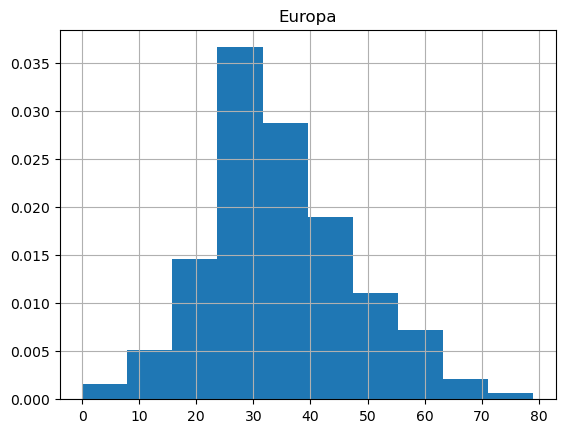

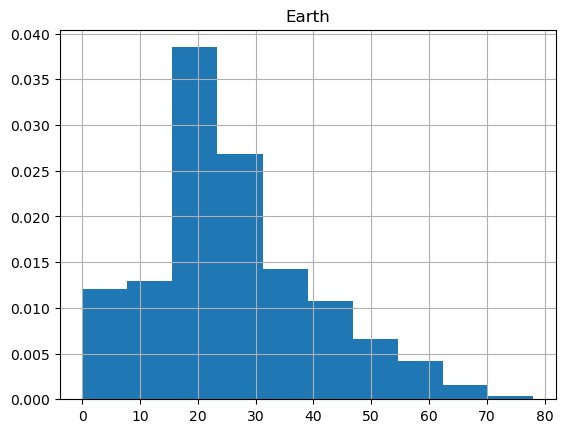

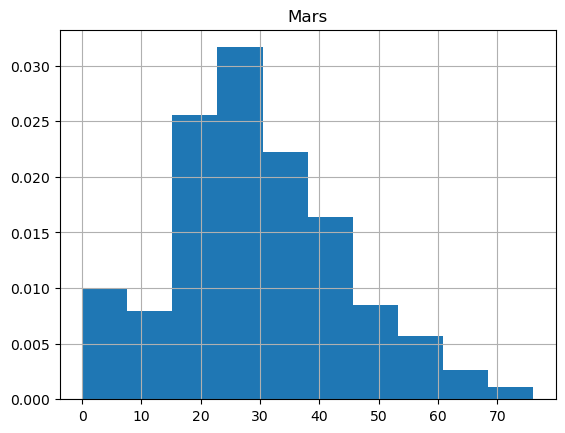

In [252]:
for pl in df["HomePlanet"].dropna().unique():
    df[df["HomePlanet"]==pl].hist(column="Age", density=True)
    plt.title(pl)
    plt.plot()

### Но этот раз мы не наблюдаем причин считать дисперсии во всех группах равными(

In [253]:
df.groupby("HomePlanet")["Age"].std()

HomePlanet
Earth     14.334676
Europa    12.994441
Mars      14.731535
Name: Age, dtype: float64

In [254]:
groups = [ df[df["HomePlanet"]==pl]["Age"] for pl in df["HomePlanet"].unique()]
stat,pval = stats.levene(*groups)
print(f"stat = {stat}\npval = {pval}")

stat = 7.374147209087503
pval = 0.000632319352809353


### Теперь задумаемся, влияет ли палуба или планета назначения на значение Transported

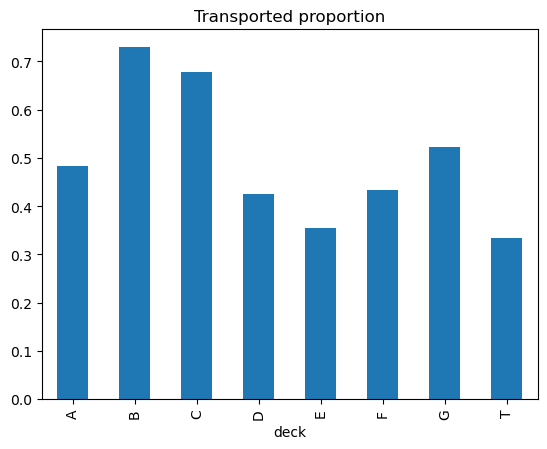

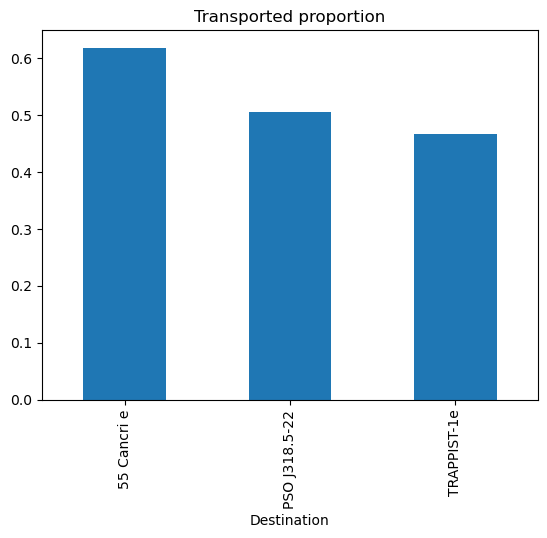

In [255]:
for col in ["deck", "Destination"]:
    df.groupby(col)["Transported"].mean().plot(kind='bar')
    plt.title("Transported proportion")
    plt.show()

### Воспользуемся тестом хи-квадрат на однородность

In [256]:
chisq_hom([np.random.binomial(1, 0.51, 1000), 
            np.random.binomial(1, 0.50, 1000),
            np.random.binomial(1, 0.49, 1000)])

np.float64(0.6414551673568545)

In [257]:
chisq_hom([np.random.binomial(1, 0.5, 1000), 
            np.random.binomial(1, 0.44, 1000),
            np.random.binomial(1, 0.45, 1000)])

np.float64(0.032766748540937085)

### Получаем, что факт перемещения действительно зависит от планеты назначения

In [258]:
groups = [df[df["Destination"]==pl]["Transported"].astype(int) for pl in df["Destination"].unique() ]
pval = chisq_hom(groups)
print(f"pval = {pval:.4f}")

pval = 0.0000


In [259]:
df.groupby("Destination")["Transported"].mean()

Destination
55 Cancri e      0.617892
PSO J318.5-22    0.504687
TRAPPIST-1e      0.467108
Name: Transported, dtype: float64

### Теперь с помощью z-теста посмотрим на попарные различия

### Для двух пар из трех было зафиксировано статистически значимое различие

In [260]:
groups = [df[df["Destination"]==pl]["Transported"].astype(int) for pl in df["Destination"].unique() ]
cnt_comparisons = len(groups) * (len(groups) - 1) / 2 

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        pval, (l,r) = bstest(groups[i], groups[j])
        corr_pval = min(cnt_comparisons * pval, 1)
        print(f"for groups {df["Destination"].unique()[i]} and {df["Destination"].unique()[j]}")
        print(f"corrected pval = {corr_pval:.4f}")
        print(f"0.95% conf int for diff in proportions:\n({l:.4f}, {r:.4f})")
        print()

for groups TRAPPIST-1e and PSO J318.5-22
corrected pval = 0.2222
0.95% conf int for diff in proportions:
(-0.0789, 0.0037)

for groups TRAPPIST-1e and 55 Cancri e
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(-0.1796, -0.1219)

for groups PSO J318.5-22 and 55 Cancri e
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(-0.1593, -0.0671)



### Теперь то же самое но для палубы

In [261]:
df.groupby("deck")["Transported"].mean()

deck
A    0.483568
B    0.730109
C    0.677796
D    0.425197
E    0.354286
F    0.434330
G    0.522041
T    0.333333
Name: Transported, dtype: float64

### Ожидаемо.

In [262]:
groups = [df[df["deck"]==d]["Transported"].astype(int) for d in "ABCDEF" ]
pval = chisq_hom(groups)
print(f"pval = {pval:.4f}")

pval = 0.0000


### Теперь попарные различия

### C учётом поправки Бонферрони статистически НЕзначимыми являются различия между палубами
### AD AF BC DE DF

In [263]:
groups = [df[df["deck"]==d]["Transported"].astype(int) for d in "ABCDEF" ]
cnt_comparisons = len(groups) * (len(groups) - 1) / 2 

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        pval, (l,r) = bstest(groups[i], groups[j])
        corr_pval = min(cnt_comparisons * pval, 1)
        print(f"for groups {"ABCDEF"[i]} and {"ABCDEF"[j]}")
        print(f"corrected pval = {corr_pval:.4f}")
        print(f"0.95% conf int for diff in proportions:\n({l:.4f}, {r:.4f})")
        print()

for groups A and B
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(-0.3219, -0.1711)

for groups A and C
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(-0.2711, -0.1174)

for groups A and D
corrected pval = 1.0000
0.95% conf int for diff in proportions:
(-0.0251, 0.1418)

for groups A and E
corrected pval = 0.0102
0.95% conf int for diff in proportions:
(0.0534, 0.2052)

for groups A and F
corrected pval = 1.0000
0.95% conf int for diff in proportions:
(-0.0210, 0.1195)

for groups B and C
corrected pval = 0.6535
0.95% conf int for diff in proportions:
(0.0015, 0.1031)

for groups B and D
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(0.2445, 0.3653)

for groups B and E
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(0.3265, 0.4252)

for groups B and F
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(0.2557, 0.3359)

for groups C and D
corrected pval = 0.0000
0.95% conf int for diff in proportions:
(0